In [15]:
import numpy as np
import seaborn as sns
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import math
import os
from matplotlib import colors as mcolors
import matplotlib.dates as mdates

In [154]:
# моя собственная библиотека для финансовых расчетов
import importlib
import FinanceLib 
importlib.reload(FinanceLib)

<module 'FinanceLib' from 'c:\\Users\\Vladimir\\Documents\\МФТИ\\Диплом\\code\\FinanceLib.py'>

In [17]:
# получаем данные 

tickers = {
    # 'Cisco': 'CSCO',
    'Intel': 'INTC',
    'Oracle': 'ORCL',
    'Qualcomm': 'QCOM',
    'Amazon' : 'AMZN',
    'Check Point Software': 'CHKP',
}

tech_companies = FinanceLib.download_data(tickers, start='1997-01-01', end='2025-01-01')
tech_companies

c:\Users\Vladimir\Documents\МФТИ\Диплом\code\FinanceLib.py:132: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed
c:\Users\Vladimir\Documents\МФТИ\Диплом\code\FinanceLib.py:132: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed
c:\Users\Vladimir\Documents\МФТИ\Диплом\code\FinanceLib.py:132: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed
c:\Users\Vladimir\Documents\МФТИ\Диплом\code\FinanceLib.py:132: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start, end=end)
[********************

{'Intel': Price           Close       High        Low       Open     Volume
 Ticker           INTC       INTC       INTC       INTC       INTC
 Date                                                             
 1997-01-02   9.214556   9.329406   9.020193   9.311737   97639200
 1997-01-03   9.779971   9.788806   9.373577   9.400081   95648000
 1997-01-06   9.815310  10.018508   9.735799   9.832980  120549600
 1997-01-07  10.133357  10.142192   9.682789   9.793223   96153600
 1997-01-08  10.053844  10.292380  10.019610  10.177530  125510400
 ...               ...        ...        ...        ...        ...
 2024-12-24  20.400000  20.400000  19.959999  20.219999   29884000
 2024-12-26  20.440001  20.670000  20.080000  20.230000   39846200
 2024-12-27  20.299999  20.610001  20.090000  20.209999   48260800
 2024-12-30  19.820000  20.110001  19.730000  20.010000   59608100
 2024-12-31  20.049999  20.400000  19.879999  19.990000   49846700
 
 [7046 rows x 5 columns],
 'Oracle': Price         

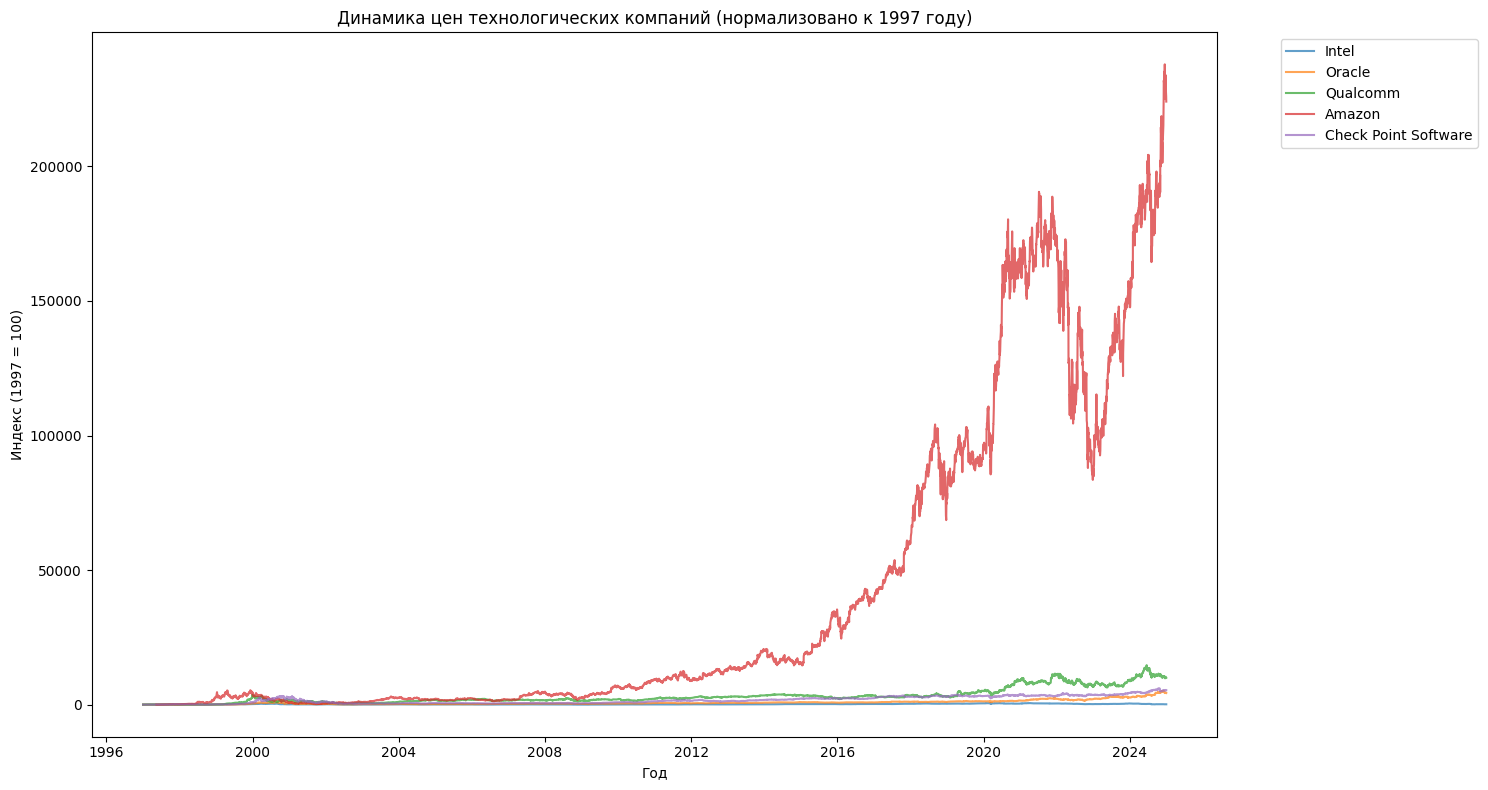

In [18]:
plt.figure(figsize=(15, 8))

for company, data in tech_companies.items():
    if not data.empty:
        # Нормализуем цены
        normalized = data['Close'] / data['Close'].iloc[0] * 100
        plt.plot(normalized.index, normalized, label=company, alpha=0.7)

plt.title('Динамика цен технологических компаний (нормализовано к 1997 году)')
plt.xlabel('Год')
plt.ylabel('Индекс (1997 = 100)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(False)
plt.tight_layout()
plt.show()

In [19]:
import importlib
importlib.reload(FinanceLib)

<module 'FinanceLib' from 'c:\\Users\\Vladimir\\Documents\\МФТИ\\Диплом\\code\\FinanceLib.py'>

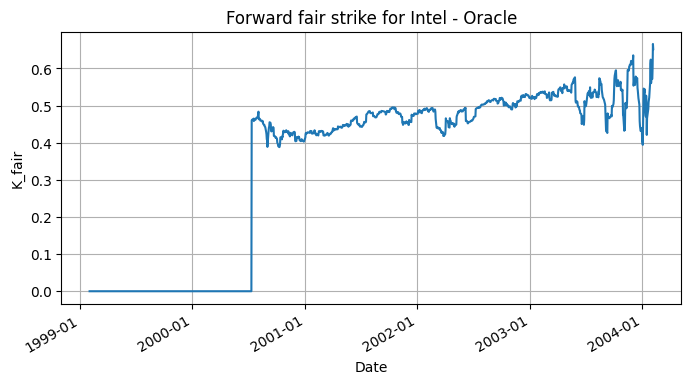

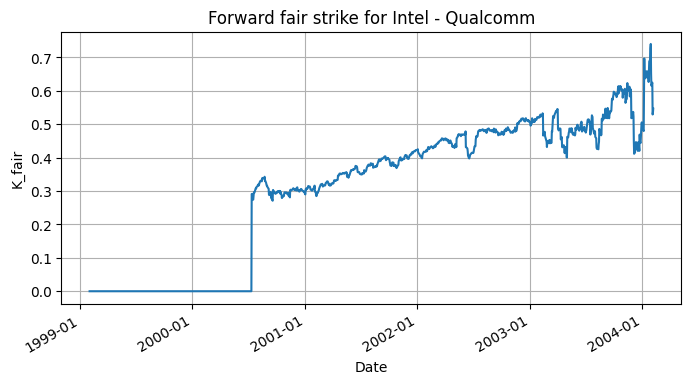

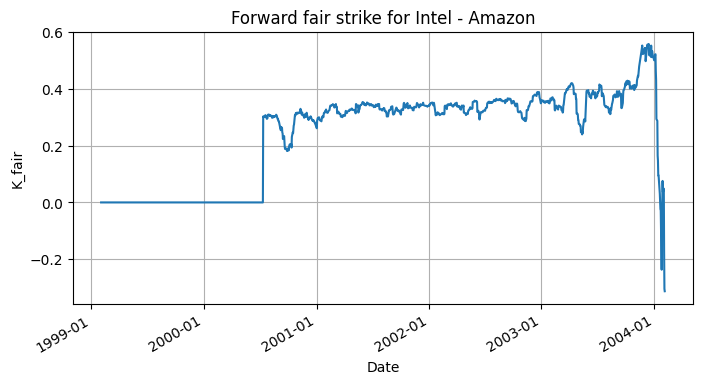

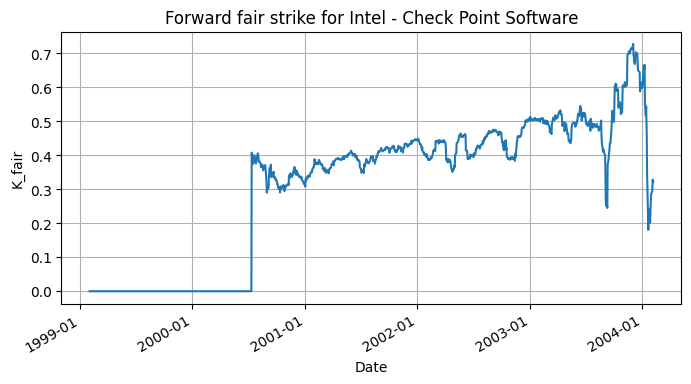

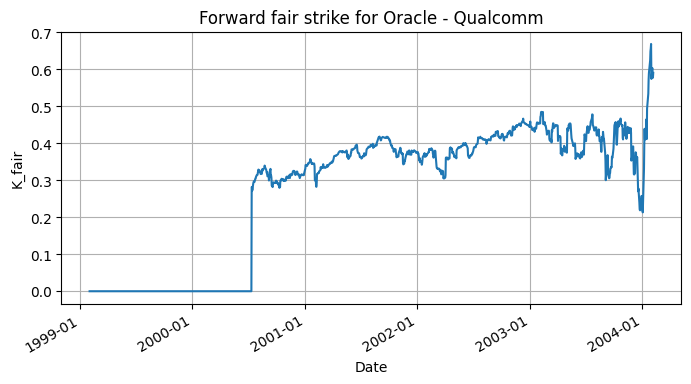

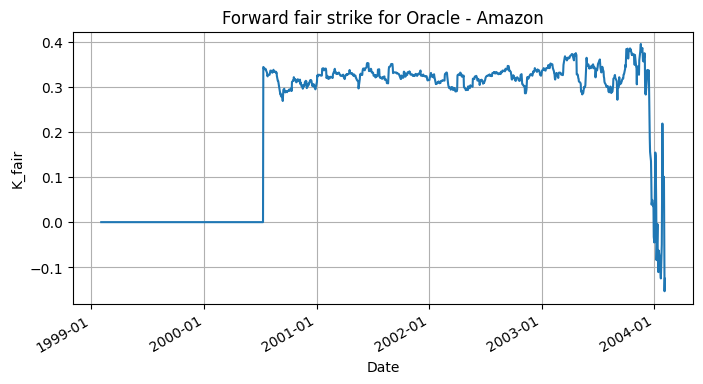

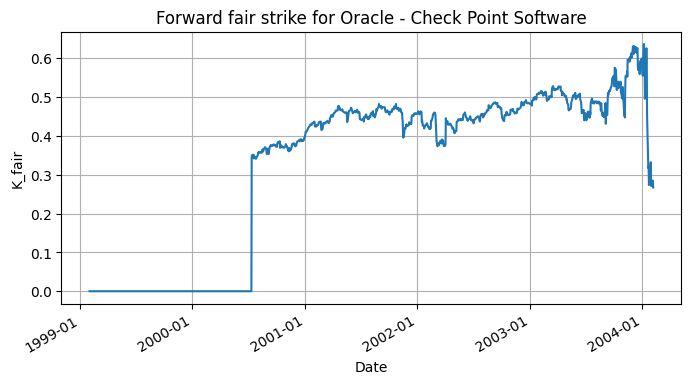

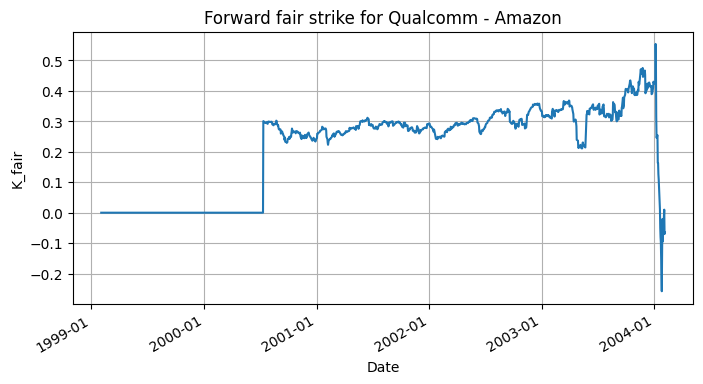

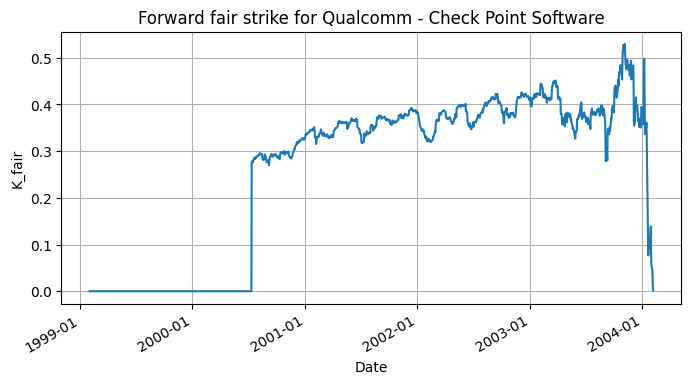

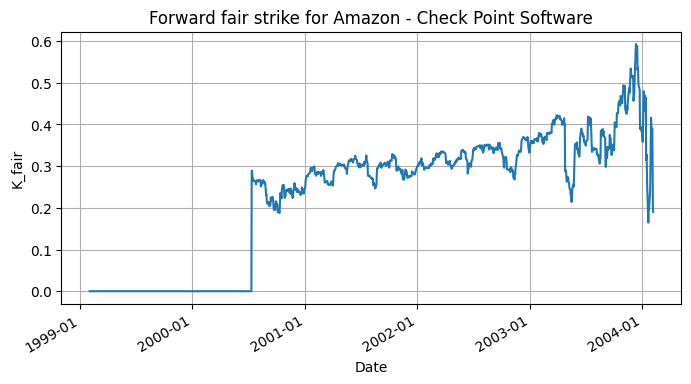

In [20]:
CORR_WID_SIZE = 21 # окно для корреляций в 2 месяца 
WIND_SIZE = 365 # окно для первичной оценки корреляционного свопа (нужно стававить больше, чем для корреляций, чтобы было достаточно данных для оценки)

# преобразуем цены в лог‑доходности начиная с заданной даты
# (новый параметр start_date позволяет отфильтровать данные)
logs_returns = FinanceLib.compute_log_returns_dict(
    tech_companies,
    start_date='1999-01-01',
)

# попарные корреляциии для всех активов на все возможные временные промежутки 
corr_matrix = FinanceLib.rolling_correlation_matrices(logs_returns, window=CORR_WID_SIZE)

T = 5.0
delta = 1/252

curve_mats = FinanceLib.fair_strike_forward_curve_from_corr_matrices(
    corr_matrix, T=T, window_size=WIND_SIZE, delta_t=delta, ar_p=1
)

curve_mats_zero = {d: m.fillna(0) for d, m in curve_mats.items()}
# start='1997-01-01', end='2025-01-01'

# просто для примера печатаем данные по ценам на своп 
pair_series = {}

dates = sorted(curve_mats_zero.keys())
assets = list(curve_mats_zero[dates[0]].index)
for i, a in enumerate(assets):
    for j in range(i + 1, len(assets)):
        b = assets[j]
        vals = [curve_mats_zero[d].loc[a, b] for d in dates]
        pair_series[(a, b)] = pd.Series(vals, index=dates)

for (a, b), series in pair_series.items():
    plt.figure(figsize=(8, 4))
    plt.plot(series.index, series.values)#, marker="o")
    plt.title(f"Forward fair strike for {a} - {b}")
    plt.xlabel("Date")
    plt.ylabel("K_fair")
    plt.grid(True)
    ax = plt.gca()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.gcf().autofmt_xdate()
    plt.show()


In [70]:
# ------------------------------------------------------------------
# Датасет: fair strike корреляционных свопов (не опционы) для разных T + цены активов.
#
# Важно про даты:
# - Первая дата в corr_matrix ≈ через CORR_WID_SIZE дней лог-доходностей (у вас ~21 день → ~1999-02).
# - T в годах — срочность свопа от даты оценки; fair strike есть после прогрева WIND_SIZE точек ряда ρ
#   (см. fair_strike_forward_curve_from_rho в FinanceLib). Строки с NaN по свопам ниже отфильтрованы.

logs_returns = FinanceLib.compute_log_returns_dict(
    tech_companies,
    start_date='1998-01-01',
)

corr_matrix = FinanceLib.rolling_correlation_matrices(logs_returns, window=CORR_WID_SIZE)

T_array = [0.25, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0]
records = []

for Tval in T_array:
    mats = FinanceLib.fair_strike_forward_curve_from_corr_matrices(
        corr_matrix, T=Tval, window_size=WIND_SIZE, delta_t=delta
    )
    for date, mat in mats.items():
        for i, a in enumerate(mat.index):
            for j, b in enumerate(mat.columns):
                if j <= i:
                    continue
                v = mat.loc[a, b]
                if pd.isna(v):
                    continue
                records.append(
                    {
                        "date": date,
                        "type": "SWAP",
                        "T": Tval,
                        "asset1_name": a,
                        "asset2_name": b,
                        "value": float(v),
                    }
                )

# добавляем цены базовых активов
for asset, df in tech_companies.items():
    if "Close" not in df.columns:
        continue
    for date in df.index:
        price = df.loc[date, "Close"]
        records.append(
            {
                "date": pd.to_datetime(date),
                "type": "ASSET",
                "T": 1,
                "asset1_name": asset,
                "asset2_name": None,
                "value": float(price),
            }
        )

portfolio_df = pd.DataFrame(records)
portfolio_df.head()

C:\Users\Vladimir\AppData\Local\Temp\ipykernel_996\560236604.py:55: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  "value": float(price),


,date,type,T,asset1_name,asset2_name,value
0,1999-07-14,SWAP,0.25,Intel,Oracle,0.419749
1,1999-07-14,SWAP,0.25,Intel,Qualcomm,0.214906
2,1999-07-14,SWAP,0.25,Intel,Amazon,0.362704
3,1999-07-14,SWAP,0.25,Intel,Check Point Software,0.252452
4,1999-07-14,SWAP,0.25,Oracle,Qualcomm,0.200808


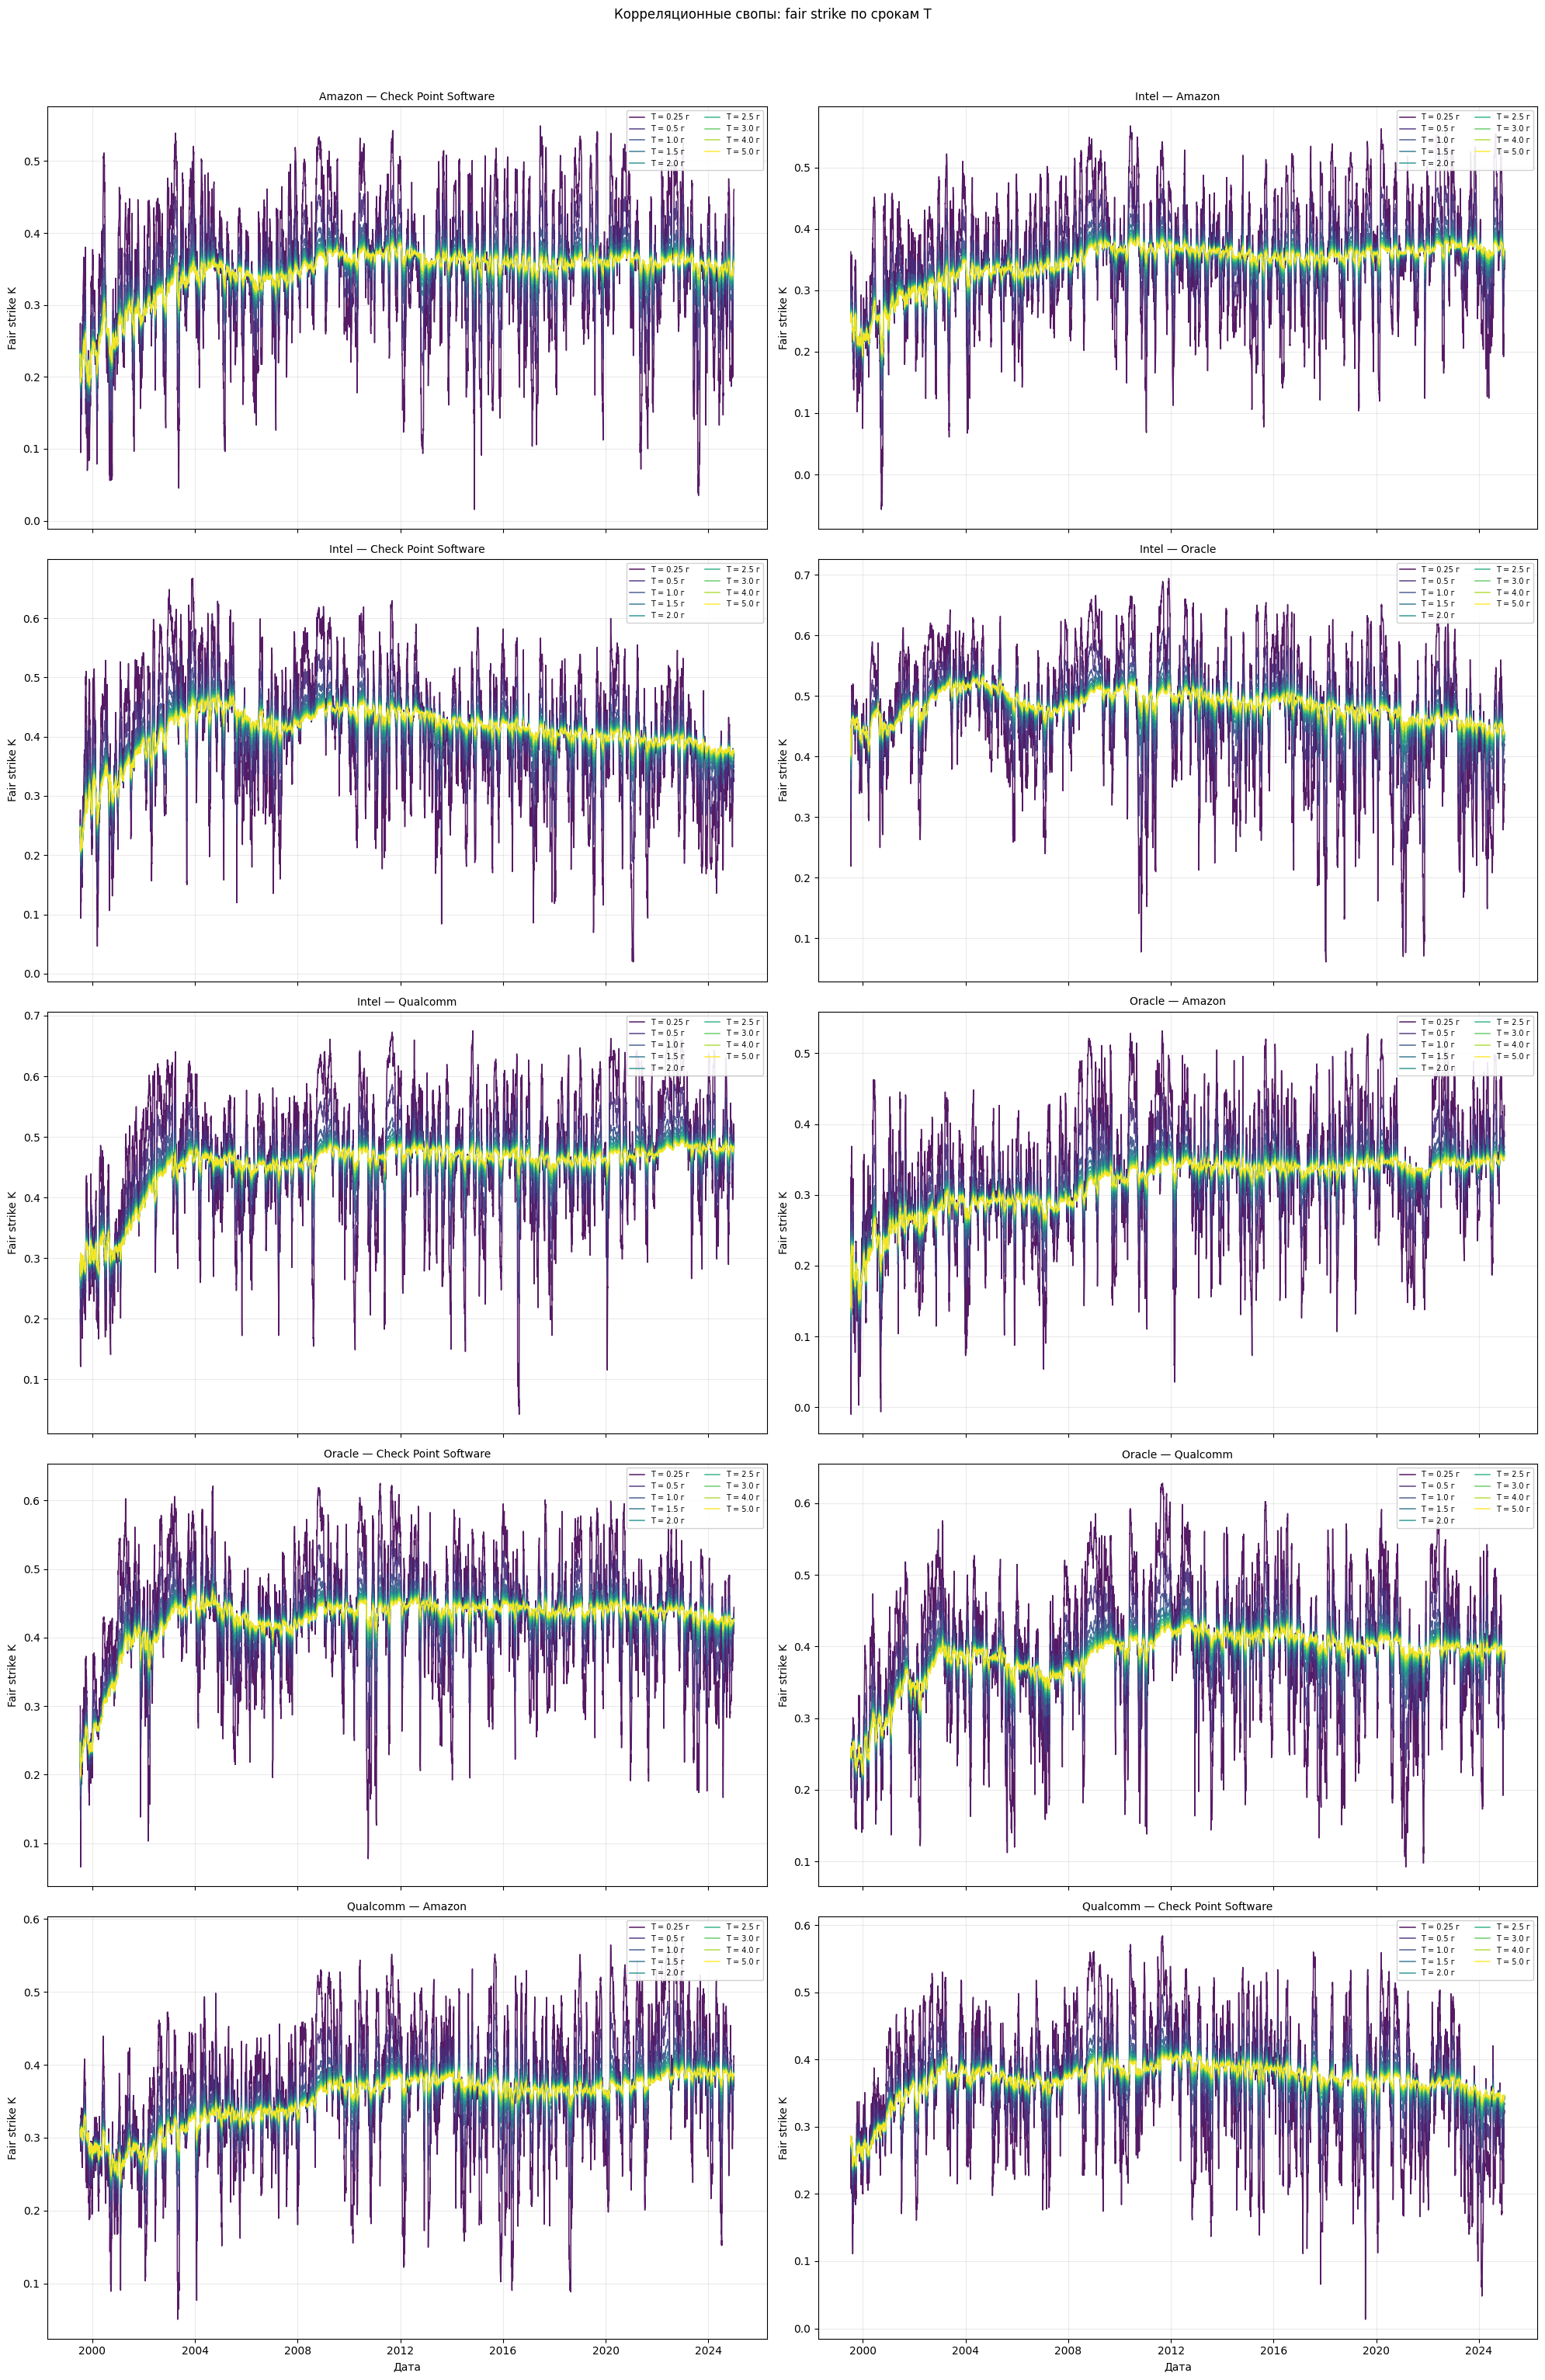

In [55]:
# Fair strike корреляционных свопов по всем парам: на каждом subplot — две компании,
# цветные линии — разные сроки T (годы), те же уровни, что в T_array при сборке portfolio_df.

swap_df = portfolio_df[portfolio_df["type"] == "SWAP"].copy()
if swap_df.empty:
    print("Нет строк SWAP в portfolio_df — сначала выполните ячейку выше.")
else:
    pair_keys = (
        swap_df[["asset1_name", "asset2_name"]]
        .drop_duplicates()
        .sort_values(["asset1_name", "asset2_name"])
        .itertuples(index=False, name=None)
    )
    pair_list = list(pair_keys)

    Ts = sorted(swap_df["T"].dropna().unique())
    n_pairs = len(pair_list)
    ncols = min(2, n_pairs) if n_pairs else 1
    nrows = int(np.ceil(n_pairs / ncols)) if n_pairs else 1

    fig, axes = plt.subplots(
        nrows, ncols, figsize=(10 * ncols, 6 * nrows), sharex=True, squeeze=False
    )

    for idx, (a1, a2) in enumerate(pair_list):
        r, c = divmod(idx, ncols)
        ax = axes[r][c]
        sub_pair = swap_df[
            (swap_df["asset1_name"] == a1) & (swap_df["asset2_name"] == a2)
        ]
        for k, Tval in enumerate(Ts):
            s = sub_pair[sub_pair["T"] == Tval].sort_values("date")
            if s.empty:
                continue
            tnorm = k / (len(Ts) - 1) if len(Ts) > 1 else 0.5
            ax.plot(
                s["date"],
                s["value"],
                color=plt.cm.viridis(tnorm),
                linewidth=1.1,
                alpha=0.9,
                label=f"T = {Tval} г",
            )
        ax.set_title(f"{a1} — {a2}", fontsize=10)
        ax.set_ylabel("Fair strike K")
        ax.grid(True, alpha=0.25)
        ax.legend(fontsize=7, loc="upper right", ncol=2, framealpha=0.9)

    for j in range(n_pairs, nrows * ncols):
        r, c = divmod(j, ncols)
        axes[r][c].set_visible(False)

    for c in range(ncols):
        axes[nrows - 1][c].set_xlabel("Дата")

    fig.suptitle("Корреляционные свопы: fair strike по срокам T", fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()


 ## далее запускаем смуляции порфеля

In [138]:
# Номиналы свопов: ключи (asset1_name, asset2_name, T) — как в portfolio_df (имена из tickers, не INTC/ORCL).
SWAP_NOTIONAL_EACH = 2
swap_deltas = FinanceLib.uniform_swap_deltas_from_portfolio_df(portfolio_df, SWAP_NOTIONAL_EACH)
# Равные доли notional_scale/n_swaps на своп: swap_deltas = None
# Свой частичный dict: для ключей не из словаря номинал остаётся как при swap_deltas = None


In [139]:
def simulate_portfolio(portfolio_df, deltas=None):
    """Симуляция портфеля (FinanceLib): равная начальная долларовая линия на каждый актив
    (w·P одинаковы на входе, сумма долей w равна notional_scale; здесь notional_scale=1).

    deltas: номинал на своп (те же ключи, что в long table). Обычно передают swap_deltas."""
    return FinanceLib.simulate_portfolio_from_long_table(
        portfolio_df,
        equal_dollar_weights=True,
        notional_scale=1.0,
        deltas=deltas,
    )

In [140]:
portfolio_sim = simulate_portfolio(portfolio_df, deltas=swap_deltas)
portfolio_sim

,date,pl_assets,pl_swaps,pl_total,asset_market_value
0,1999-07-14,0.000000,0.000000,0.000000,7.412480
1,1999-07-15,0.100274,0.000000,0.100274,7.512754
2,1999-07-16,0.146631,0.000000,0.146631,7.559112
3,1999-07-19,0.113821,0.000000,0.113821,7.526301
4,1999-07-20,-0.003108,0.000000,-0.003108,7.409373
...,...,...,...,...,...
6404,2024-12-24,177.963320,15.770779,193.734099,185.375800
6405,2024-12-26,177.230555,15.770779,193.001335,184.643036
6406,2024-12-27,174.611458,15.770779,190.382237,182.023938
6407,2024-12-30,172.668752,15.770779,188.439531,180.081232


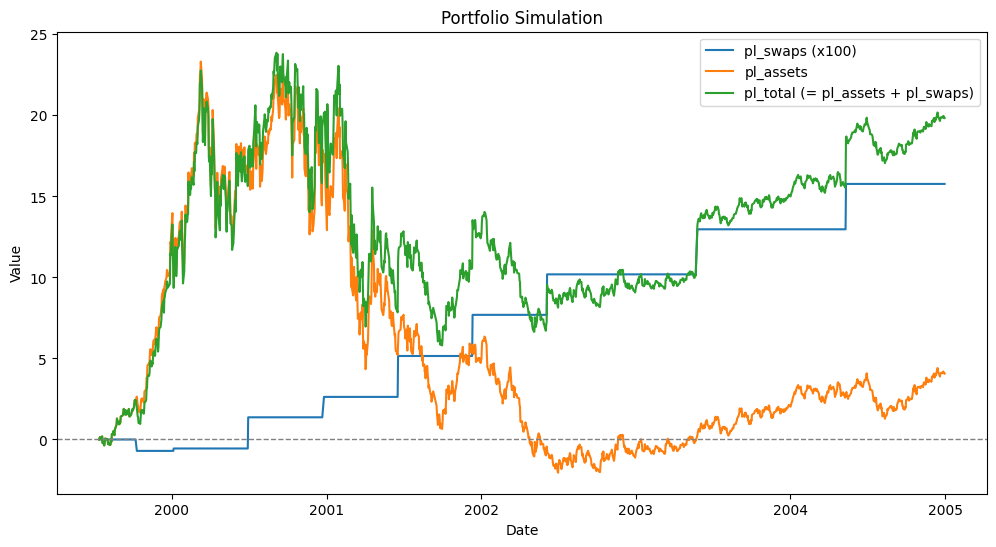

In [142]:
portfolio_df_small = portfolio_df[portfolio_df['date'] < '2005-01-01'].copy()
portfolio_sim = simulate_portfolio(portfolio_df_small, deltas=swap_deltas)

plt.figure(figsize=(12, 6))

# plt.plot(portfolio_sim['date'], portfolio_sim['asset_market_value'], label='Asset MV')
plt.plot(portfolio_sim['date'], portfolio_sim['pl_swaps'], label='pl_swaps (x100)')
plt.plot(portfolio_sim['date'], portfolio_sim['pl_assets'], label='pl_assets')
plt.plot(portfolio_sim['date'], portfolio_sim['pl_total'], label='pl_total (= pl_assets + pl_swaps)')

plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.xlabel('Date')
plt.ylabel('Value')
plt.title('Portfolio Simulation')
plt.legend()
plt.show()


In [143]:
# pl_total уже накопленный P&L с t0 — псевдо-цена без второго cumsum()
pnl_series = portfolio_sim['pl_total']
prices = 1.0 + pnl_series.astype(float)
min_val = prices.min()
if min_val <= 0:
    prices = prices - min_val + 1.0

mr_value = FinanceLib.calculate_martin_ratio(prices.values)
print(f"Martin ratio (pseudo-price) по pl_total: {mr_value:.4f}")

rets = prices.pct_change().dropna()
sharpe = rets.mean() / rets.std() * math.sqrt(252)
print(f"Sharpe ratio по pl_total: {sharpe:.4f}")


Martin ratio (pseudo-price) по pl_total: 0.0180
Sharpe ratio по pl_total: 1.0533


In [144]:
pnl_series

0        0.000000
1        0.100274
2        0.146631
3        0.113821
4       -0.003108
          ...    
1371    19.864906
1372    19.970742
1373    19.861203
1374    19.872595
1375    19.841194
Name: pl_total, Length: 1376, dtype: float64

In [65]:
# pl_swaps — накопленный P&L по свопам (лесенка)
pnl_series = portfolio_sim['pl_swaps']
prices = 1.0 + pnl_series.astype(float)
min_val = prices.min()
if min_val <= 0:
    prices = prices - min_val + 1.0

mr_value = FinanceLib.calculate_martin_ratio(prices.values)
print(f"Martin ratio (pseudo-price) по pl_swaps: {mr_value:.4f}")

rets = prices.pct_change().dropna()
sharpe = rets.mean() / rets.std() * math.sqrt(252)
print(f"Sharpe ratio по pl_swaps: {sharpe:.4f}")


Martin ratio (pseudo-price) на swap P&L: 0.0611
Sharpe ratio на swap P&L: 1.5447


# Собираем датает для получения вообще всех значения для обучения моделей

In [158]:
prices = FinanceLib.download_ml_training_prices(start="1998-01-01", end="2025-01-01")
print('Данные загружены')
log_ret, rho_pairs = FinanceLib.compute_log_returns_and_pairwise_rolling_correlations(prices, corr_window=21)
print('Лог-доходности и корреляции посчитаны')

Данные загружены
Лог-доходности и корреляции посчитаны


In [ ]:
total_df = FinanceLib.build_correlation_swap_ml_dataset(prices,
                                                        T_array=(0.25, 0.5, 1.0, 2.0, 3.0, 5.0),
                                                        corr_window=21,
                                                        ar_rho_history=252)
total_df.to_csv('excel_output/total_df.csv')

KeyboardInterrupt: 

### временно для тестов берем обрубленный датасет

In [182]:
subset_tickers = {
    "Apple": "AAPL",
    "Microsoft": "MSFT",
    # "Alphabet": "GOOGL",
    # "Amazon": "AMZN",
    # "Tesla": "TSLA",
    # "Nvidia": "NVDA",
    # "Meta": "META",
}
prices_short = {k: prices[k] for k in subset_tickers if k in prices}

In [186]:
df = FinanceLib.build_correlation_swap_ml_dataset(prices_short,
                                                  T_array=(0.25, 0.5, 1.0, 2.0, 3.0, 4.0, 5.0),
                                                  corr_window=21,
                                                  ar_rho_history=252)

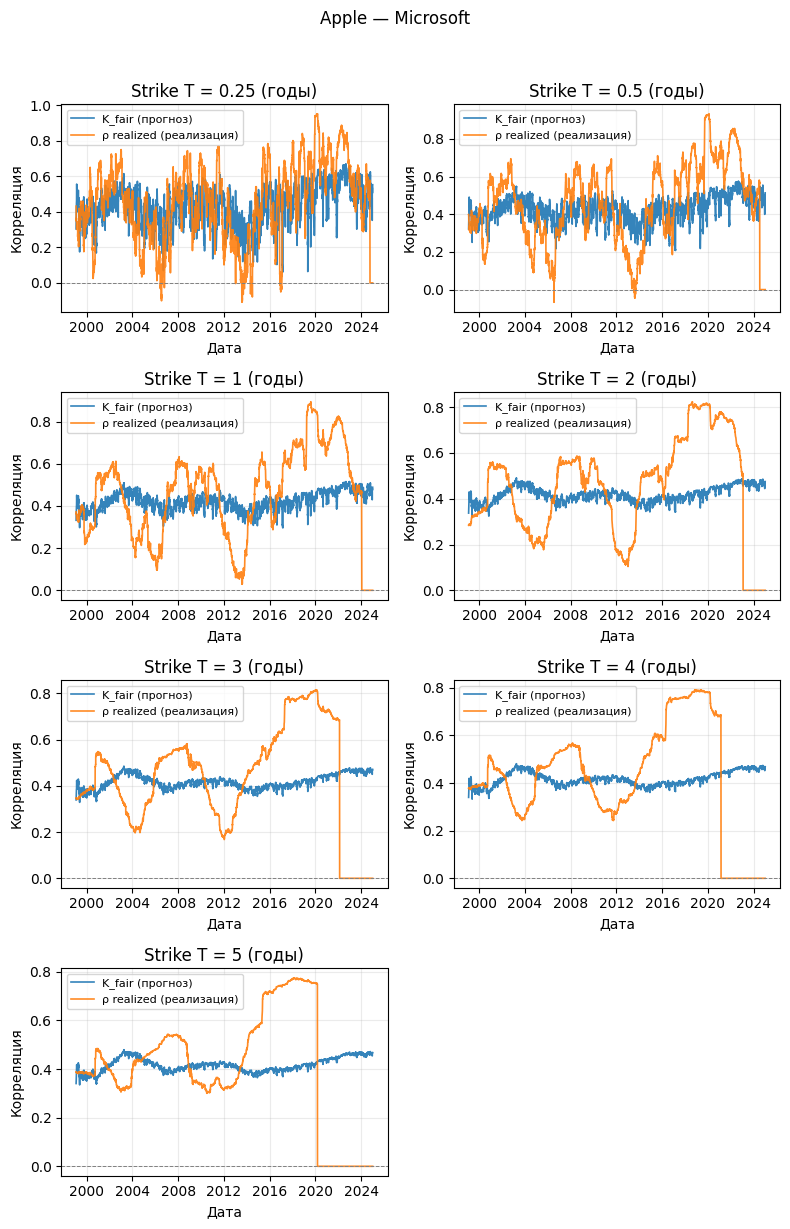

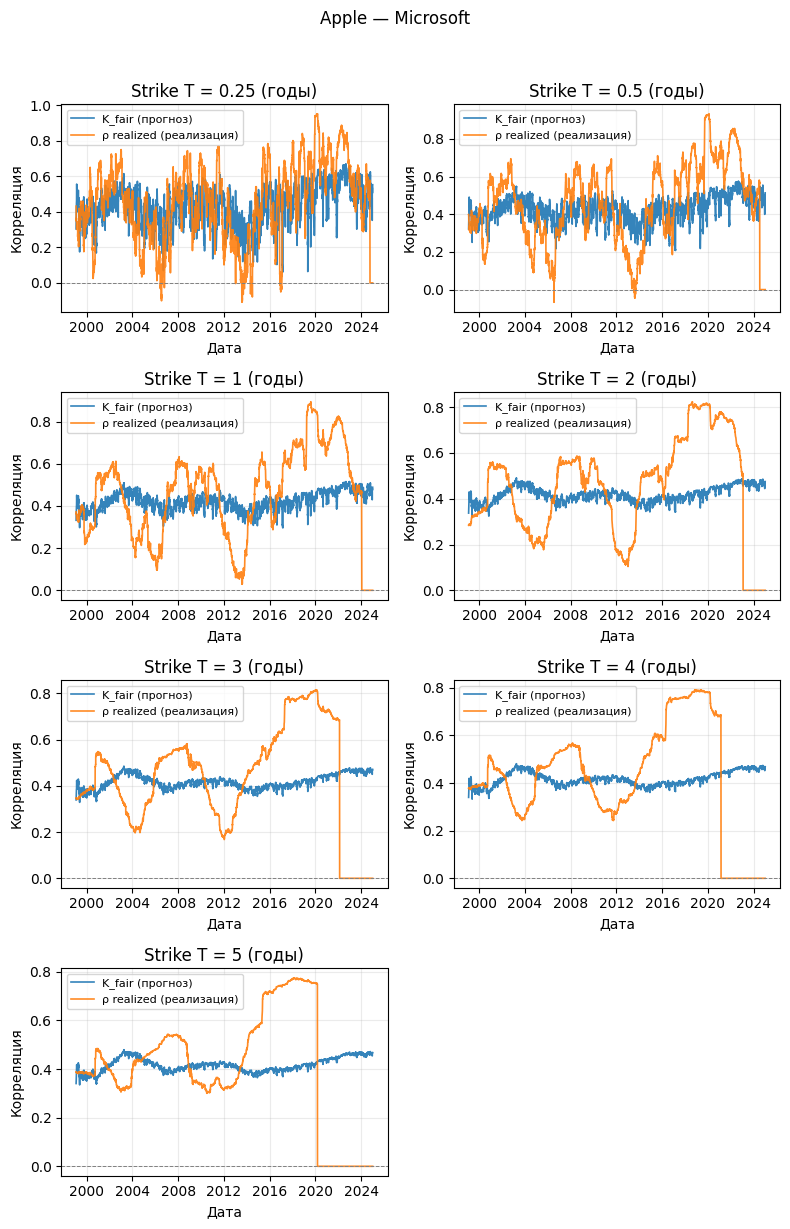

In [187]:
df_copy = df.copy()
df_copy.fillna(0, inplace=True)

figs = FinanceLib.plot_ml_dataset_fair_vs_realized_all_pairs(df_copy, ncols=2)
for f in figs:
    display(f) 

In [185]:
df

,date,type,asset1_name,asset2_name,strike,K_fair,price,log_return
0,1998-01-02,ASSET,Apple,None,NaN,NaN,0.145089,NaN
1,1998-01-02,ASSET,Microsoft,None,NaN,NaN,16.390625,NaN
2,1998-01-05,ASSET,Apple,None,NaN,NaN,0.141741,-0.023346
3,1998-01-05,ASSET,Microsoft,None,NaN,NaN,16.296875,-0.005736
4,1998-01-06,ASSET,Apple,None,NaN,NaN,0.169085,0.176400
...,...,...,...,...,...,...,...,...
52713,2024-12-31,SWAP,Apple,Microsoft,0.5,0.513199,NaN,NaN
52714,2024-12-31,SWAP,Apple,Microsoft,1.0,0.488230,NaN,NaN
52715,2024-12-31,SWAP,Apple,Microsoft,2.0,0.475337,NaN,NaN
52716,2024-12-31,SWAP,Apple,Microsoft,3.0,0.471037,NaN,NaN


In [178]:
# моя собственная библиотека для финансовых расчетов
import importlib
import FinanceLib 
importlib.reload(FinanceLib)

<module 'FinanceLib' from 'c:\\Users\\Vladimir\\Documents\\МФТИ\\Диплом\\code\\FinanceLib.py'>